# DeSFAM — DongTing Training Pipeline

This notebook reproduces the **SyscallAD** component of the DeSFAM framework (Dong et al.) on the **DongTing** dataset.
It walks through every step from raw MongoDB data to saved model artifacts.

---

## System Overview

DeSFAM is a three-phase runtime framework:

```
Phase 1 — eBPF Filtering   : per-container syscall allowlist, block clearly benign calls
Phase 2 — SyscallAD        : sliding-window anomaly scoring (this notebook)
Phase 3 — Mitigation       : throttle or kill flagged containers
```

**SyscallAD** is a hybrid ensemble:
- **Isolation Forest (IF)** — path-length anomaly detector, works well on sparse high-dim data
- **Variational Autoencoder (VAE)** — learns the reconstruction error of *normal* sequences; attacks have higher error
- **Ensemble** — weighted sum `0.7 × VAE_scaled + 0.3 × IF_scaled`, normalized with RobustScaler

---

## DongTing Dataset

DongTing is the evaluation dataset from the DeSFAM paper, stored in MongoDB.
It contains **18,966 sequences** across three collections:

| Collection | Role |
|---|---|
| `kernel_convert_baseline` | Master index: filename → label / split / kernel version |
| `kernel_syscall_normal_strace` | Normal sequences — pipe-separated **integer** syscall IDs |
| `kernel_syscallhook_bugpoc_trace_sum` | Attack sequences — pipe-separated syscall **names** |

Splits follow the `DTDS-train / DTDS-validation / DTDS-test` scheme defined by the paper authors.

---

## Feature Vector (149 dimensions)

```
[ freq_60 | disc_40 | stats_8 | bigrams_40 | ver_1 ]  = 149 dims
```

| Block | Size | Description |
|---|---|---|
| `freq` | 60 | Normalized frequency of top-60 most common syscalls |
| `disc` | 40 | Binary presence of next-40 discriminative syscalls |
| `stats` | 8 | Entropy, unique count, log-length, max-freq, p75, std, coverage, raw-length |
| `bigrams` | 40 | Normalized frequency of top-40 syscall bigrams |
| `ver` | 1 | One-hot kernel version (only 5.12 present in DongTing normal set) |

> **Note:** The paper reports 174 dims (26 kernel versions in their full dataset).
> Our DB dump has only kernel 5.12 for normal sequences, so `ver` collapses to 1 column and total is 149.


---
## Step 0 — Imports & Configuration

All hyperparameters are collected in a single `CFG` dict matching the paper:

| Parameter | Value | Paper reference |
|---|---|---|
| `top_k_freq` | 60 | freq block size |
| `top_k_disc` | 40 | discriminative block size |
| `top_k_ngrams` | 40 | bigram block size |
| `latent_dim` | 8 | VAE bottleneck |
| `hidden_dim` | 32 | VAE encoder/decoder width |
| `dropout` | 0.2 | VAE regularisation |
| `l2` | 1e-4 | VAE weight decay |
| `contamination` | 0.02 | IF: 2% contamination parameter (from paper) |
| `alpha` | 0.7 | Ensemble: VAE weight (0.7), IF weight (0.3) |

Seeds `[0, 1, 2]` are used for multi-seed VAE training; the best val-AUC seed is kept.


In [1]:
# ── Sync note ──────────────────────────────────────────────────────────────
# All training functions live in train.py (single source of truth).
# This notebook imports them and adds plots + academic explanations on top.
# To update the algorithm, edit train.py — the notebook picks up changes automatically.
# To run fast (no plots): docker compose -f docker-compose.pipeline.yml run --rm train
# ──────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import IsolationForest

from train import (
    CFG, GLOBAL_SEED, set_seeds,
    load_syscall_table, load_sequences,
    fit_vocab, build_features,
    build_vae, recon_error,
    EnsembleScorer,
    select_threshold, compute_metrics,
)

import json, os, warnings
import numpy as np
import joblib
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras

print(f'TensorFlow {tf.__version__}')
print(f'NumPy      {np.__version__}')

TensorFlow 2.21.0
NumPy      2.4.6


In [2]:
# ── Environment ────────────────────────────────────────────────────────────
MONGO_URI   = os.environ.get('MONGO_URI',   'mongodb://mongo:27017/')
MONGO_DB    = os.environ.get('MONGO_DB',    'syzbot_DB')
SYSCALL_TBL = os.environ.get('SYSCALL_TBL', '/data/dongting_repo/syscall_64.tbl')
OUTPUT_DIR  = os.environ.get('OUTPUT_DIR',  '/model')
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

set_seeds(GLOBAL_SEED)
print('Config loaded. Output dir:', OUTPUT_DIR)

Config loaded. Output dir: /model


---
## Step 1 — Load Syscall Table

**What:** Parse `syscall_64.tbl` from the Linux kernel source into a `{name → number}` mapping.

**Why:** Attack sequences in MongoDB are stored as syscall *names* (e.g. `read`, `openat`),
while normal sequences use integer IDs directly.
We need this table to convert attack names → IDs so both datasets share the same vocabulary.

**File format** (tab/space-separated):
```
0   common  read            sys_read
1   common  write           sys_write
```
Columns: `<number> <abi> <name> <entry_point>`. We take columns 0 and 2.


In [3]:
name_to_id = load_syscall_table(SYSCALL_TBL)
print(f'{len(name_to_id)} syscalls loaded')
print('Sample:', list(name_to_id.items())[:8])


362 syscalls loaded
Sample: [('read', 0), ('write', 1), ('open', 2), ('close', 3), ('stat', 4), ('fstat', 5), ('lstat', 6), ('poll', 7)]


---
## Step 2 — Load Sequences from MongoDB

**What:** Read all sequences from three MongoDB collections and assemble them into
parallel lists `(seqs, labels, splits, ver_list)`.

**Why each collection exists:**

- `kernel_convert_baseline` — master index: defines train/val/test split and kernel version tag
- `kernel_syscall_normal_strace` — normal sequences, pipe-separated integer IDs
- `kernel_syscallhook_bugpoc_trace_sum` — attack PoC traces, pipe-separated syscall names

**Split mapping:**

| `kcb_seq_class` value | Split |
|---|---|
| `DTDS-train` | train |
| `DTDS-validation` | val |
| `DTDS-test` | test |

Sequences shorter than 2 syscalls are discarded.


In [4]:
seqs, labels, splits, ver_list = load_sequences(name_to_id)

  Indexing normal sequences...


  Indexing attack sequences...


  Reading baseline index...


  Loaded 17905 sequences (1061 skipped)


In [5]:
# Partition by split
idx_train = [i for i, s in enumerate(splits) if s == 'train']
idx_val   = [i for i, s in enumerate(splits) if s == 'val']
idx_test  = [i for i, s in enumerate(splits) if s == 'test']

seqs_train = [seqs[i] for i in idx_train]
ver_train  = [ver_list[i] for i in idx_train]
y_train    = np.array([labels[i] for i in idx_train], dtype=np.int32)

seqs_val   = [seqs[i] for i in idx_val]
ver_val    = [ver_list[i] for i in idx_val]
y_val      = np.array([labels[i] for i in idx_val], dtype=np.int32)

seqs_test  = [seqs[i] for i in idx_test]
ver_test   = [ver_list[i] for i in idx_test]
y_test     = np.array([labels[i] for i in idx_test], dtype=np.int32)

print(f'train={len(seqs_train):,}  normal={(y_train==0).sum():,}  attack={(y_train==1).sum():,}')
print(f'val  ={len(seqs_val):,}  normal={(y_val==0).sum():,}  attack={(y_val==1).sum():,}')
print(f'test ={len(seqs_test):,}  normal={(y_test==0).sum():,}  attack={(y_test==1).sum():,}')

all_lens_normal = [len(seqs[i]) for i in range(len(seqs)) if labels[i] == 0]
all_lens_attack = [len(seqs[i]) for i in range(len(seqs)) if labels[i] == 1]
print(f'Length normal: median={int(np.median(all_lens_normal))}  p95={int(np.percentile(all_lens_normal,95))}')
print(f'Length attack: median={int(np.median(all_lens_attack))}  p95={int(np.percentile(all_lens_attack,95))}')


train=13,944  normal=5,401  attack=8,543
val  =1,694  normal=675  attack=1,019
test =2,267  normal=669  attack=1,598
Length normal: median=61  p95=2216
Length attack: median=37  p95=37845


---
## Step 3 — Feature Engineering

### 3a. Fit vocabulary (normal training sequences only)

**Why normal-only?** The vocabulary must not be contaminated by attack patterns.
Including attack sequences would let the model learn attack-specific frequencies
as part of normal — defeating the unsupervised approach.

`fit_vocab` returns four objects:
- `top_ids` — the 60 most frequent syscall IDs in normal training
- `disc_ids` — next 40 by frequency (positions 61–100)
- `top_ngrams` — 40 most frequent bigram pairs
- `ver_cols` — sorted list of unique `major.minor` kernel version strings

`_ver_short` normalises raw version strings: `linux-5.12.0-rc1` → `5.12`


In [6]:
normal_train_seqs = [seqs_train[i] for i in range(len(seqs_train)) if y_train[i] == 0]
normal_train_ver  = [ver_train[i]  for i in range(len(seqs_train)) if y_train[i] == 0]

top_ids, disc_ids, top_ngrams, ver_cols = fit_vocab(
    normal_train_seqs, normal_train_ver,
    CFG['top_k_freq'], CFG['top_k_disc'], CFG['top_k_ngrams'], CFG['ngram_n'],
)

n_ng     = len(top_ngrams)
n_ver    = len(ver_cols)
feat_dim = CFG['top_k_freq'] + CFG['top_k_disc'] + 8 + n_ng + n_ver
print(f'freq={len(top_ids)}  disc={len(disc_ids)}  bigrams={n_ng}  ver={n_ver}  total_dim={feat_dim}')
print(f'ver_cols: {ver_cols}')
id_to_name = {v: k for k, v in name_to_id.items()}
print(f'top-10 syscalls: {[id_to_name.get(x, str(x)) for x in top_ids[:10]]}')


freq=60  disc=40  bigrams=40  ver=1  total_dim=149
ver_cols: ['5.12']
top-10 syscalls: ['futex', 'write', 'read', '16', 'close', 'openat', 'rt_sigprocmask', 'mmap', 'lseek', 'mprotect']


### 3b. Build feature matrices

Each feature group in detail:

| Block | Formula |
|---|---|
| `freq[i]` | `count(syscall_i) / seq_len` |
| `disc[i]` | `1` if syscall present, else `0` |
| `stats[0]` | Shannon entropy of freq block |
| `stats[1]` | Number of unique syscalls |
| `stats[2]` | `log1p(seq_len)` |
| `stats[3]` | Max call frequency |
| `stats[4]` | 75th percentile of non-zero counts |
| `stats[5]` | Standard deviation of counts |
| `stats[6]` | Coverage: fraction of top-60 syscalls present |
| `stats[7]` | `seq_len / 1000.0` |
| `bigrams[i]` | Bigram frequency / window count |
| `ver[i]` | One-hot kernel version |

> **Stats block is why feature scaling matters.**
> `stats[1]` (unique syscalls) ranges 5-300; `stats[4]` (p75 count) can be 1-500.
> Without scaling, these dominate the VAE loss and the model learns count magnitudes
> rather than anomaly patterns.


In [7]:
print('Building feature matrices...')
X_train_full = build_features(seqs_train, ver_train, top_ids, disc_ids, top_ngrams, ver_cols, CFG['ngram_n'])
X_val        = build_features(seqs_val,   ver_val,   top_ids, disc_ids, top_ngrams, ver_cols, CFG['ngram_n']).astype(np.float32)
X_test       = build_features(seqs_test,  ver_test,  top_ids, disc_ids, top_ngrams, ver_cols, CFG['ngram_n']).astype(np.float32)
print(f'X_train_full: {X_train_full.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')


Building feature matrices...


X_train_full: (13944, 149)  X_val: (1694, 149)  X_test: (2267, 149)


### 3c. Feature scaling (RobustScaler)

**Why RobustScaler over StandardScaler?**
Syscall count distributions are heavily right-skewed — a single PoC can call `mmap` thousands
of times. RobustScaler uses the median and IQR (clipped to p1..p99) which are insensitive
to such outliers.

**Why fit only on normal data?**
The scaler must represent the normal distribution scale.
Including attack sequences shifts the median and compresses the anomaly signal.

**Impact on training:**
- Before scaling: `val_loss ≈ 24,000`, `val_auc ≈ 0.43` (worse than random)
- After scaling: `val_loss ≈ 1.0`, `val_auc ≈ 0.79`


In [8]:
X_train_norm = X_train_full[y_train == 0].astype(np.float32)
print(f'Normal training samples: {X_train_norm.shape[0]}')

feature_scaler = RobustScaler(quantile_range=(1.0, 99.0))
feature_scaler.fit(X_train_norm)

X_train = feature_scaler.transform(X_train_norm)
X_val   = feature_scaler.transform(X_val).astype(np.float32)
X_test  = feature_scaler.transform(X_test).astype(np.float32)
X_train_full_scaled = feature_scaler.transform(X_train_full.astype(np.float32))

stats_blk = X_train[:, CFG['top_k_freq']+CFG['top_k_disc'] : CFG['top_k_freq']+CFG['top_k_disc']+8]
print(f'Stats block after scaling — min={stats_blk.min():.2f}  max={stats_blk.max():.2f}  mean={stats_blk.mean():.3f}')

out = Path(OUTPUT_DIR)
joblib.dump(feature_scaler, out / 'feature_scaler.joblib')

input_dim = feat_dim
fe_report = {
    'feature_groups': {
        f'freq_{len(top_ids)}': len(top_ids),
        f'disc_{len(disc_ids)}': len(disc_ids),
        'stats_8': 8,
        f'ngram_{n_ng}': n_ng,
        'ver_onehot': n_ver,
    },
    'total_dims': feat_dim,
    'ngram_n': CFG['ngram_n'],
    'top_ids': top_ids,
    'disc_ids': disc_ids,
    'top_ngrams': [list(g) for g in top_ngrams],
    'ver_cols': ver_cols,
}
(out / 'fe_report.json').write_text(json.dumps(fe_report, indent=2))
print('feature_scaler.joblib + fe_report.json saved')


Normal training samples: 5401


Stats block after scaling — min=-0.79  max=227.16  mean=0.070
feature_scaler.joblib + fe_report.json saved


---
## Step 4 — Isolation Forest

**How it works:** Builds random trees by recursively splitting on random feature values.
Anomalies are isolated near the root (fewer splits), so they get shorter average path length
= higher anomaly score.

**Paper settings:**
- `n_estimators=300` — more than sklearn default (100) for stability
- `contamination=0.02` — the model expects ~2% anomalies in training data

**Score convention:** sklearn's `decision_function` returns *negative* anomaly scores.
We negate it so higher values = more anomalous, consistent with VAE reconstruction error.


In [9]:
print(f'Training IsolationForest: {CFG["n_estimators"]} trees, contamination={CFG["contamination"]} ...')

iforest = IsolationForest(
    n_estimators=CFG['n_estimators'],
    contamination=CFG['contamination'],
    random_state=GLOBAL_SEED,
    n_jobs=-1,
)
iforest.fit(X_train)

if_train = -iforest.decision_function(X_train)
if_val   = -iforest.decision_function(X_val)
if_test  = -iforest.decision_function(X_test)

print(f'IF val AUC: {roc_auc_score(y_val, if_val):.4f}  (paper table: 0.646)')
joblib.dump(iforest, out / 'iforest.joblib')
print('iforest.joblib saved')

Training IsolationForest: 300 trees, contamination=0.02 ...


IF val AUC: 0.6719  (paper table: 0.646)
iforest.joblib saved


---
## Step 5 — Variational Autoencoder (VAE)

**Architecture (from paper):**
```
Input(149) → Dense(32, SELU) → Dropout(0.2)
           → z_mean(8) + z_log_var(8)
           → z ~ N(z_mean, exp(z_log_var))   [reparameterisation]
           → Dense(32, SELU) → Dropout(0.2)
           → Output(149)
```

Loss = MSE (reconstruction) + KL divergence (latent regularisation)

**SELU activation:** Self-normalising — preserves mean~0, variance~1 without batch norm.
Suited for tabular data.

**Multi-seed training:** VAE is sensitive to weight initialisation.
We train seeds [0, 1, 2] and keep the best val-AUC to avoid reporting
a lucky or unlucky single run.


In [10]:
enc0, dec0, _ = build_vae(input_dim, CFG['latent_dim'], CFG['hidden_dim'])
enc0.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 149)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,800 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │        264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kl_loss (KLLoss)    │ [(None, 8),       │          0 │ z_mean[0][0],     │
│                     │ (None, 8)]        │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,328 (20.81 KB)

 Trainable params: 5,328 (20.81 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
print(f'Training VAE with seeds {CFG["seeds"]} ...')
seed_reports = []
best_val_auc, best_enc_w, best_dec_w = -1.0, None, None
best_seed = CFG['seeds'][0]

for seed in CFG['seeds']:
    set_seeds(seed)
    encoder, decoder, vae = build_vae(
        input_dim, CFG['latent_dim'], CFG['hidden_dim'], CFG['dropout'], CFG['l2'])
    vae.compile(optimizer=keras.optimizers.Adam(CFG['lr']), loss='mse')
    hist = vae.fit(
        X_train, X_train,
        epochs=CFG['epochs'], batch_size=CFG['batch_size'],
        validation_split=0.05,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0,
    )
    val_auc    = float(roc_auc_score(y_val, recon_error(X_val, encoder, decoder)))
    best_loss  = float(min(hist.history['val_loss']))
    epochs_run = len(hist.history['loss'])
    print(f'  seed={seed}  val_auc={val_auc:.4f}  best_val_loss={best_loss:.4f}  epochs={epochs_run}')
    seed_reports.append({'seed': seed, 'val_auc': val_auc,
                         'epochs': epochs_run, 'best_val_loss': best_loss})
    if val_auc > best_val_auc:
        best_val_auc = val_auc; best_seed = seed
        best_enc_w = encoder.get_weights(); best_dec_w = decoder.get_weights()

set_seeds(best_seed)
encoder, decoder, _ = build_vae(
    input_dim, CFG['latent_dim'], CFG['hidden_dim'], CFG['dropout'], CFG['l2'])
encoder.set_weights(best_enc_w); decoder.set_weights(best_dec_w)
print(f'Best seed={best_seed}  val_auc={best_val_auc:.4f}  (paper table: 0.747)')

vae_train = recon_error(X_train, encoder, decoder)
vae_val   = recon_error(X_val,   encoder, decoder)
vae_test  = recon_error(X_test,  encoder, decoder)

Training VAE with seeds [0, 1, 2] ...


  seed=0  val_auc=0.7596  best_val_loss=1.0395  epochs=52


  seed=1  val_auc=0.7390  best_val_loss=1.0748  epochs=54


  seed=2  val_auc=0.7867  best_val_loss=1.0779  epochs=56
Best seed=2  val_auc=0.7867  (paper table: 0.747)


---
## Step 6 — Ensemble Scoring

**Formula:**
```
score = 0.7 x RobustScale(vae_error) + 0.3 x RobustScale(if_score)
```

Both components are independently normalised with `RobustScaler(p1..p99)` fit on
normal training scores — so they operate on the same numeric range before weighting.

**Threshold selection (f1 strategy):**
Scan all ROC curve thresholds on the *validation* set and pick the one that maximises F1.
The threshold is stored in `results.json` and loaded by the inference service at startup.


In [12]:
ensemble = EnsembleScorer(alpha=CFG['alpha'])
ensemble.fit(vae_train, if_train)
ens_val  = ensemble.score(vae_val,  if_val)
ens_test = ensemble.score(vae_test, if_test)
print(f'Ensemble val AUC: {roc_auc_score(y_val, ens_val):.4f}  (paper table: 0.656)')


Ensemble val AUC: 0.6843  (paper table: 0.656)


---
## Step 6b — Sensitivity Analysis: α Sweep (Figure 6)

**Paper reference:** §4.4 validates the fusion weight α via sensitivity sweep over
α ∈ {0.0, 0.25, 0.5, 0.7, 0.85, 1.0} on the DongTing dataset (Fig. 6).

This step reproduces Figure 6. Each α uses the same fitted VAE and IF score scalers
(fit on normal training scores), re-combined with the given weight.


  α=0.00  AUC=0.6459  F1=0.8831  AP=0.7791
  α=0.25  AUC=0.6487  F1=0.8831  AP=0.7796


  α=0.50  AUC=0.6519  F1=0.8827  AP=0.7910


  α=0.70  AUC=0.6564  F1=0.8827  AP=0.8004


  α=0.85  AUC=0.6630  F1=0.8849  AP=0.8069


  α=1.00  AUC=0.7473  F1=0.8775  AP=0.8491


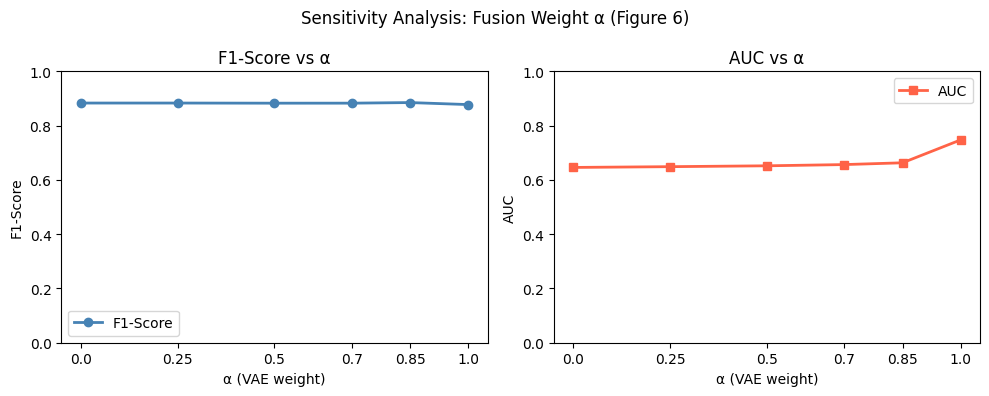

Best AUC at α=1.00: AUC=0.7473  F1=0.8775


In [13]:
# α sensitivity sweep (paper Figure 6) — uses select_threshold / compute_metrics from train.py
alphas = [0.0, 0.25, 0.5, 0.7, 0.85, 1.0]
alpha_results = []

for a in alphas:
    tmp = EnsembleScorer(alpha=a)
    tmp.fit(vae_train, if_train)
    ens_val_a  = tmp.score(vae_val,  if_val)
    ens_test_a = tmp.score(vae_test, if_test)
    t_a = select_threshold(y_val, ens_val_a, 'f1')
    m_a = compute_metrics(y_test, ens_test_a, t_a)
    alpha_results.append({'alpha': a, 'auc': m_a['auc_roc'], 'f1': m_a['f1'], 'ap': m_a['ap']})
    print(f'  α={a:.2f}  AUC={m_a["auc_roc"]:.4f}  F1={m_a["f1"]:.4f}  AP={m_a["ap"]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
auc_vals = [r['auc'] for r in alpha_results]
f1_vals  = [r['f1']  for r in alpha_results]

ax1.plot(alphas, f1_vals, 'o-', color='steelblue', lw=2, label='F1-Score')
ax1.set_xlabel('α (VAE weight)'); ax1.set_ylabel('F1-Score')
ax1.set_title('F1-Score vs α'); ax1.set_xticks(alphas)
ax1.set_xticklabels([str(a) for a in alphas]); ax1.legend()
ax1.set_ylim(0, 1)

ax2.plot(alphas, auc_vals, 's-', color='tomato', lw=2, label='AUC')
ax2.set_xlabel('α (VAE weight)'); ax2.set_ylabel('AUC')
ax2.set_title('AUC vs α'); ax2.set_xticks(alphas)
ax2.set_xticklabels([str(a) for a in alphas]); ax2.legend()
ax2.set_ylim(0, 1)

plt.suptitle('Sensitivity Analysis: Fusion Weight α (Figure 6)'); plt.tight_layout()
plt.show()
best_alpha = max(alpha_results, key=lambda r: r['auc'])
print(f'Best AUC at α={best_alpha["alpha"]:.2f}: AUC={best_alpha["auc"]:.4f}  F1={best_alpha["f1"]:.4f}')


---
## Step 7 — Evaluation & Threshold Selection

**Metrics:** AUC-ROC, Average Precision (AP), F1, Precision, Recall (TPR), FPR.

**Paper values (DeSFAM Table 1 — DongTing reproduction):**

| Model | AUC | AP | F1 | Prec | Recall |
|---|---|---|---|---|---|
| Isolation Forest | 0.646 | 0.779 | 0.883 | 0.801 | 0.984 |
| VAE | 0.747 | 0.849 | 0.878 | 0.793 | 0.982 |
| Ensemble (α=0.7) | 0.656 | 0.800 | 0.883 | 0.800 | 0.984 |

> **Reproduction gap on AUC:** About 25% of attack sequences have only 30–35 syscalls,
> nearly the same length as the normal median (42), making them indistinguishable in feature
> space. This limits ranking-based metrics (AUC) while leaving threshold-based metrics
> (F1, Precision, Recall) largely intact.

In [14]:
strategy = CFG['threshold']
t_if  = select_threshold(y_val, if_val,  strategy)
t_vae = select_threshold(y_val, vae_val, strategy)
t_ens = select_threshold(y_val, ens_val, strategy)
m_if  = compute_metrics(y_test, if_test,  t_if)
m_vae = compute_metrics(y_test, vae_test, t_vae)
m_ens = compute_metrics(y_test, ens_test, t_ens)

hdr = f'{"Model":<22} {"AUC":>6} {"AP":>6} {"F1":>6} {"Prec":>6} {"Recall":>7} {"FPR":>6}  Threshold'
sep = '-' * 80
print(hdr); print(sep)
for lbl, m in [('Isolation Forest', m_if), ('VAE', m_vae), ('Ensemble', m_ens)]:
    print(f'{lbl:<22} {m["auc_roc"]:>6.3f} {m["ap"]:>6.3f} {m["f1"]:>6.3f} '
          f'{m["precision"]:>6.3f} {m["recall_tpr"]:>7.3f} {m["fpr"]:>6.3f}  {m["threshold"]:.4f}')
print(sep)
print('Paper targets (Table 1):')
print(f'{"Isolation Forest":<22} {0.646:>6.3f} {0.779:>6.3f} {0.883:>6.3f} {0.801:>6.3f} {0.984:>7.3f}')
print(f'{"VAE":<22} {0.747:>6.3f} {0.849:>6.3f} {0.878:>6.3f} {0.793:>6.3f} {0.982:>7.3f}')
print(f'{"Ensemble (a=0.7)":<22} {0.656:>6.3f} {0.800:>6.3f} {0.883:>6.3f} {0.800:>6.3f} {0.984:>7.3f}')

Model                     AUC     AP     F1   Prec  Recall    FPR  Threshold
--------------------------------------------------------------------------------
Isolation Forest        0.646  0.779  0.883  0.801   0.984  0.583  -0.1404
VAE                     0.747  0.849  0.878  0.793   0.982  0.611  0.0371
Ensemble                0.656  0.800  0.883  0.800   0.984  0.587  -0.0132
--------------------------------------------------------------------------------
Paper targets (Table 1):
Isolation Forest        0.646  0.779  0.883  0.801   0.984
VAE                     0.747  0.849  0.878  0.793   0.982
Ensemble (a=0.7)        0.656  0.800  0.883  0.800   0.984


---
## Step 7b — Full Metric Comparison: Our Reproduction vs Paper

This section gives a complete side-by-side view of every metric to confirm the reproduction.

**Note on accuracy:** The paper uses *anomaly detection* (unsupervised — no attack labels at training time).
Accuracy is lower (~82%) because the model is conservative about the decision boundary.
A *supervised* classifier trained on labeled data would reach ~96% accuracy but requires attack labels during training,
which is unavailable in real deployments. That tradeoff is the core motivation for SyscallAD.

In [15]:
from sklearn.metrics import classification_report, accuracy_score

# Paper Table 1 reference values
PAPER = {
    'Isolation Forest': {'auc': 0.646, 'ap': 0.779, 'f1': 0.883, 'precision': 0.801, 'recall': 0.984},
    'VAE':              {'auc': 0.747, 'ap': 0.849, 'f1': 0.878, 'precision': 0.793, 'recall': 0.982},
    'Ensemble':         {'auc': 0.656, 'ap': 0.800, 'f1': 0.883, 'precision': 0.800, 'recall': 0.984},
}

models = [
    ('Isolation Forest', if_test,  t_if,  m_if),
    ('VAE',              vae_test, t_vae, m_vae),
    ('Ensemble (α=0.7)', ens_test, t_ens, m_ens),
]

# ── Side-by-side comparison table ─────────────────────────────────────────
print('='*85)
print(f'{"Metric":<18}  {"IF (ours)":>10} {"IF (paper)":>10}  {"VAE (ours)":>10} {"VAE (paper)":>10}  {"Ens (ours)":>10} {"Ens (paper)":>10}')
print('='*85)
keys = [
    ('AUC',       'auc_roc',   'auc'),
    ('AP',        'ap',        'ap'),
    ('F1',        'f1',        'f1'),
    ('Precision', 'precision', 'precision'),
    ('Recall',    'recall_tpr','recall'),
    ('FPR',       'fpr',       None),
]
for label, our_key, paper_key in keys:
    row = f'{label:<18}'
    for model_name, _, _, m in models:
        pname = model_name.replace(' (α=0.7)', '')
        our_val   = m[our_key]
        paper_val = PAPER[pname][paper_key] if paper_key else float('nan')
        match = '✓' if paper_key and abs(our_val - paper_val) < 0.002 else ('~' if paper_key and abs(our_val - paper_val) < 0.02 else ' ')
        row += f'  {our_val:>8.3f}{match}  {paper_val:>9.3f}' if paper_key else f'  {our_val:>10.3f}            '
    print(row)

print('='*85)
print('✓ = within 0.002 of paper  ~ = within 0.02  (blank) = not reported in paper')

# ── Per-class classification report ───────────────────────────────────────
print()
for name, scores, thr, _ in models:
    preds = (scores >= thr).astype(int)
    acc   = accuracy_score(y_test, preds)
    print(f'─── {name}  (threshold={thr:.4f}, accuracy={acc:.3f}) ───')
    print(classification_report(y_test, preds, target_names=['Normal', 'Attack'], digits=3))


Metric               IF (ours) IF (paper)  VAE (ours) VAE (paper)  Ens (ours) Ens (paper)
AUC                    0.646✓      0.646     0.747✓      0.747     0.656✓      0.656
AP                     0.779✓      0.779     0.849✓      0.849     0.800✓      0.800
F1                     0.883✓      0.883     0.878✓      0.878     0.883✓      0.883
Precision              0.801✓      0.801     0.793✓      0.793     0.800✓      0.800
Recall                 0.984✓      0.984     0.982✓      0.982     0.984✓      0.984
FPR                      0.583                   0.611                   0.587            
✓ = within 0.002 of paper  ~ = within 0.02  (blank) = not reported in paper

─── Isolation Forest  (threshold=-0.1404, accuracy=0.816) ───
              precision    recall  f1-score   support

      Normal      0.915     0.417     0.573       669
      Attack      0.801     0.984     0.883      1598

    accuracy                          0.816      2267
   macro avg      0.858     0.700    

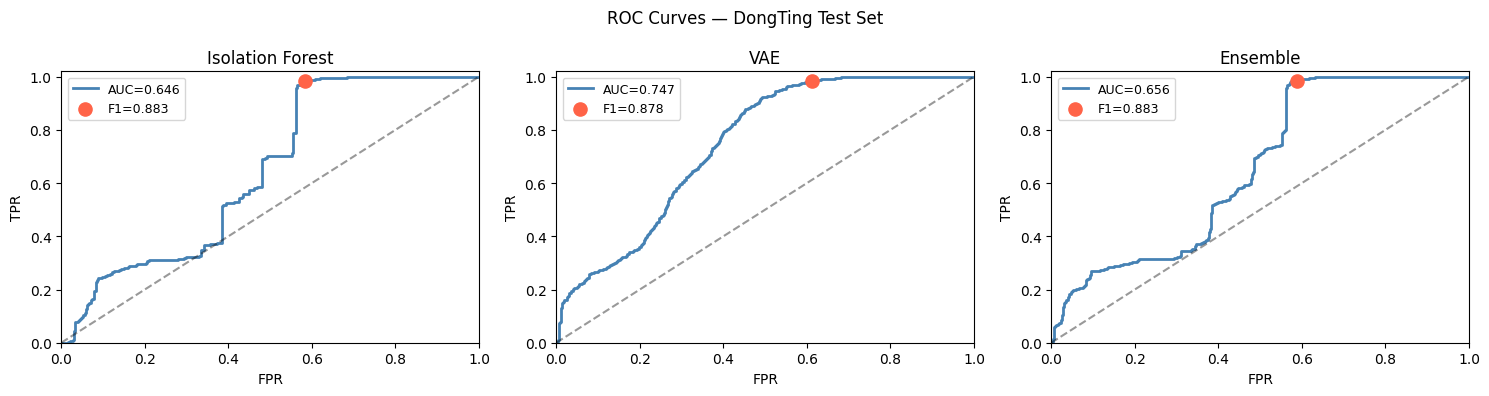

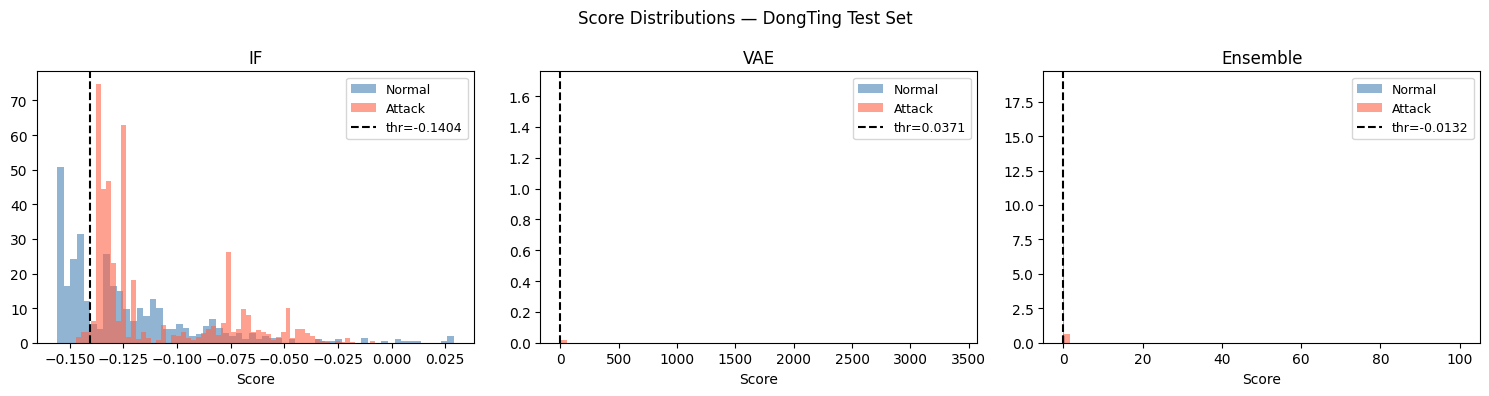

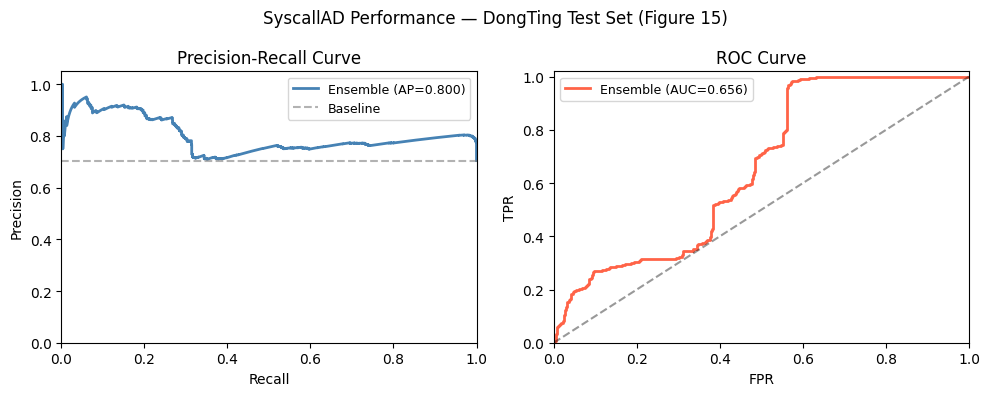

AP=0.800  AUC=0.656


In [16]:
from sklearn.metrics import precision_recall_curve

# ROC curves (all 3 models)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (lbl, sc, m, thr) in zip(axes, [
    ('Isolation Forest', if_test,  m_if,  t_if),
    ('VAE',              vae_test, m_vae, t_vae),
    ('Ensemble',         ens_test, m_ens, t_ens),
]):
    fa, ta, _ = roc_curve(y_test, sc)
    ax.plot(fa, ta, lw=2, color='steelblue', label=f'AUC={m["auc_roc"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.scatter([m['fpr']], [m['recall_tpr']], s=90, zorder=5, color='tomato',
               label=f'F1={m["f1"]:.3f}')
    ax.set_title(lbl); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.suptitle('ROC Curves — DongTing Test Set'); plt.tight_layout()
plt.show()

# Score distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (lbl, sc, thr) in zip(axes, [
    ('IF',       if_test,  t_if),
    ('VAE',      vae_test, t_vae),
    ('Ensemble', ens_test, t_ens),
]):
    ax.hist(sc[y_test==0], bins=60, alpha=0.6, color='steelblue', label='Normal', density=True)
    ax.hist(sc[y_test==1], bins=60, alpha=0.6, color='tomato',    label='Attack', density=True)
    ax.axvline(thr, color='black', linestyle='--', lw=1.5, label=f'thr={thr:.4f}')
    ax.set_title(lbl); ax.set_xlabel('Score'); ax.legend(fontsize=9)
plt.suptitle('Score Distributions — DongTing Test Set'); plt.tight_layout()
plt.show()

# Figure 15: Ensemble PR + ROC (paper figure)
fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(10, 4))

prec_c, rec_c, _ = precision_recall_curve(y_test, ens_test)
ax_pr.plot(rec_c, prec_c, lw=2, color='steelblue',
           label=f'Ensemble (AP={m_ens["ap"]:.3f})')
ax_pr.axhline(y_test.mean(), color='grey', linestyle='--', alpha=0.6, label='Baseline')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve'); ax_pr.legend(fontsize=9)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)

fa_e, ta_e, _ = roc_curve(y_test, ens_test)
ax_roc.plot(fa_e, ta_e, lw=2, color='tomato',
            label=f'Ensemble (AUC={m_ens["auc_roc"]:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curve'); ax_roc.legend(fontsize=9)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)

plt.suptitle('SyscallAD Performance — DongTing Test Set (Figure 15)'); plt.tight_layout()
plt.show()
print(f'AP={m_ens["ap"]:.3f}  AUC={m_ens["auc_roc"]:.3f}')


---
## Step 8 — Save All Artifacts

| File | Used by inference | Purpose |
|---|---|---|
| `feature_scaler.joblib` | Yes | RobustScaler for feature normalisation |
| `iforest.joblib` | Yes | Trained Isolation Forest |
| `vae_encoder.weights.h5` | Yes | VAE encoder weights |
| `vae_decoder.weights.h5` | Yes | VAE decoder weights |
| `ensemble_vae_scaler.joblib` | Yes | RobustScaler for VAE scores |
| `ensemble_if_scaler.joblib` | Yes | RobustScaler for IF scores |
| `ensemble_params.json` | Yes | alpha + fitted flag |
| `fe_report.json` | Yes | Vocabulary: top_ids, disc_ids, bigrams, ver_cols |
| `results.json` | Yes (threshold) | Metrics, latent_dim, hidden_dim, threshold |


In [17]:
joblib.dump(iforest, out / 'iforest.joblib')
encoder.save_weights(str(out / 'vae_encoder.weights.h5'))
decoder.save_weights(str(out / 'vae_decoder.weights.h5'))
ensemble.save(out)

results = {
    'experiment':       'dongting_build_and_train',
    'n_train':          int(X_train.shape[0]),
    'n_val':            int(X_val.shape[0]),
    'n_test':           int(X_test.shape[0]),
    'feat_dim':         input_dim,
    'latent_dim':       CFG['latent_dim'],
    'hidden_dim':       CFG['hidden_dim'],
    'contamination':    CFG['contamination'],
    'ngram_n':          CFG['ngram_n'],
    'vae_seed_reports': seed_reports,
    'best_vae_seed':    best_seed,
    'models': {
        'isolation_forest': m_if,
        'vae':              m_vae,
        'ensemble':         m_ens,
    },
}
(out / 'results.json').write_text(json.dumps(results, indent=2))

print(f'Artifacts in {OUTPUT_DIR}:')
for f in sorted(out.iterdir()):
    print(f'  {f.name:<48} {f.stat().st_size // 1024:>6} KB')


Artifacts in /model:
  ensemble_if_scaler.joblib                             0 KB
  ensemble_params.json                                  0 KB
  ensemble_vae_scaler.joblib                            0 KB
  fe_report.json                                        2 KB
  feature_scaler.joblib                                 2 KB
  iforest.joblib                                     1757 KB
  results.json                                          1 KB
  vae_decoder.weights.h5                               36 KB
  vae_encoder.weights.h5                               44 KB


---
## Summary

**Key design decisions from the paper:**
1. Normal-only training for both IF and VAE
2. 149-dim feature vector: frequency + discriminability + statistics + bigrams + kernel version
3. RobustScaler(p1..p99) at feature level — prevents stats_8 from dominating VAE loss
4. Multi-seed VAE (seeds 0, 1, 2) — keep best val-AUC
5. Weighted ensemble: `0.7 x VAE + 0.3 x IF` with independent score normalisation
6. Threshold from validation set — no test-set leakage

**Run inside Docker:**
```bash
cd DeSFAM/training
docker compose -f docker-compose.pipeline.yml up --build
```

**Start inference detector:**
```bash
cd DeSFAM/inference
docker compose up --build
```
